# VeloceReduction — Reduce one observing night

This notebook is the master workflow for reducing a complete Veloce observing
night.

**Input:** `observations/YYMMDD/`  
**Output:** `reductions/vr_X.Y.Z/YYMMDD/`

Detailed algorithms are implemented in the `velocereduction` Python modules.
This notebook intentionally contains only the main reduction steps.

## 0. Setup

Choose the night and reduction settings.

When run interactively as a notebook, the values below are used directly.
When converted to `reduce_night.py`, the night is supplied on the command line.

In [14]:
import sys
import argparse

import numpy as np

from astropy.table import Table

import matplotlib.pyplot as plt

from velocereduction import (
    __version__,
    utils,
    extraction,
    flat,
    tramlines,
    calibration,
    wavelength
)


def running_in_notebook():
    """True for an interactive Jupyter notebook, False for reduce_night.py."""
    if 'ipykernel' in sys.modules:
        return True
    else:
        return False


IN_NOTEBOOK = running_in_notebook()

In [15]:
if IN_NOTEBOOK:

    # -------------------------------------------------------------------------
    # Interactive notebook settings
    # -------------------------------------------------------------------------

    night = '001122'            # Observing night in YYMMDD format,
                                # e.g. 001122, which is the reference night
    # night = '260703'            

    log_level = 'DEBUG'          # DEBUG / INFO / WARNING / ERROR
    diagnostics = 'full'       # none / basic / full

    extraction_mode = 'fibre'  # summed / fibre
    overwrite = False

else:

    # -------------------------------------------------------------------------
    # Command-line settings for reduce_night.py
    # -------------------------------------------------------------------------

    parser = argparse.ArgumentParser(
        description='Reduce one complete Veloce observing night.'
    )

    parser.add_argument(
        'night',
        help='Observing night in YYMMDD format, e.g. 001122'
    )

    parser.add_argument(
        '--log-level',
        choices=['DEBUG', 'INFO', 'WARNING', 'ERROR'],
        default='INFO'
    )

    parser.add_argument(
        '--diagnostics',
        choices=['none', 'basic', 'full'],
        default='basic'
    )

    parser.add_argument(
        '--extraction-mode',
        choices=['summed', 'fibre'],
        default='summed'
    )

    parser.add_argument(
        '--overwrite',
        action='store_true'
    )

    args = parser.parse_args()

    night = args.night
    log_level = args.log_level
    diagnostics = args.diagnostics
    extraction_mode = args.extraction_mode
    overwrite = args.overwrite

In [16]:
config = utils.ReductionConfig(
    night=night,
    log_level=log_level,
    diagnostics=diagnostics,
    extraction_mode=extraction_mode,
    overwrite=overwrite,
)

paths = utils.prepare_reduction(config, version=__version__)
logger = utils.setup_logging(config, paths)

logger.info('Starting VeloceReduction %s for night %s', __version__, night)
logger.info('Diagnostics: %s', diagnostics)
logger.info('Extraction mode: %s', extraction_mode)

print(f'\nNight:             {night}')
print(f'VeloceReduction:   {__version__}')
print(f'Logging:           {log_level}')
print(f'Diagnostics:       {diagnostics}')
print(f'Extraction:        {extraction_mode}')
print(f'Output:            {paths.root}')

INFO     ========================================================================
INFO     Starting VeloceReduction
INFO     Night: 001122
INFO     Log level: DEBUG
INFO     Diagnostics: full
INFO     Extraction mode: fibre
INFO     Output directory: /Users/buder/velocereduction/reductions/vr_0.7.0/001122
INFO     Starting VeloceReduction 0.7.0 for night 001122
INFO     Diagnostics: full
INFO     Extraction mode: fibre

Night:             001122
VeloceReduction:   0.7.0
Logging:           DEBUG
Diagnostics:       full
Extraction:        fibre
Output:            /Users/buder/velocereduction/reductions/vr_0.7.0/001122


## 1. Identify observations

**Input:** raw observations and observing log  
**Output:** night overview and `reduction_input_YYMMDD.txt`

All observations are classified once at the beginning of the reduction.
Later stages use this table rather than repeatedly reading and classifying
raw FITS headers.

In [17]:
reduction_input = utils.identify_observations(config, paths)

utils.write_reduction_input(reduction_input, config, paths)

if IN_NOTEBOOK:
    display(reduction_input)

INFO     Using observing log 001122-AAT-reference.log
INFO     Identified 20 observing runs
INFO       Dark       3
INFO       FibTh      3
INFO       Flat       3
INFO       Science    7
INFO       SimLC      1
INFO       SimTh      3
INFO     Wrote reduction input to /Users/buder/velocereduction/reductions/vr_0.7.0/001122/reduction_input_001122.txt


run,type,object,exptime,mjd_obs,mjd_mid,has_ccd1,has_ccd2,has_ccd3,use_ccd1,use_ccd2,use_ccd3,file_ccd1,file_ccd2,file_ccd3,files_complete,use,lc_requested,lc_ut,lc_exp,comments,issue,calibration_block
str4,str7,str16,float64,float64,float64,bool,bool,bool,bool,bool,bool,str70,str70,str70,bool,bool,bool,str8,float64,str44,str18,str16
0001,SimTh,SimThLong,180.0,60359.34174913,60359.34279079667,True,False,False,True,False,False,/Users/buder/velocereduction/observations/001122/ccd_1/22nov10001.fits,/Users/buder/velocereduction/observations/001122/ccd_2/22nov20001.fits,/Users/buder/velocereduction/observations/001122/ccd_3/22nov30001.fits,False,True,False,,nan,N/A to limit storage,"Missing CCD2, CCD3",cal003
0002,SimTh,SimThLong,60.0,60359.35892373,60359.35927095222,False,True,False,False,True,False,/Users/buder/velocereduction/observations/001122/ccd_1/22nov10002.fits,/Users/buder/velocereduction/observations/001122/ccd_2/22nov20002.fits,/Users/buder/velocereduction/observations/001122/ccd_3/22nov30002.fits,False,True,False,,nan,N/A to limit storage,"Missing CCD1, CCD3",cal003
0003,SimTh,SimTh,15.0,60359.36918084,60359.36926764556,False,False,True,False,False,True,/Users/buder/velocereduction/observations/001122/ccd_1/22nov10003.fits,/Users/buder/velocereduction/observations/001122/ccd_2/22nov20003.fits,/Users/buder/velocereduction/observations/001122/ccd_3/22nov30003.fits,False,True,False,,nan,Median of 10 runs from 240219.,"Missing CCD1, CCD2",cal003
0004,FibTh,ARC-ThAr,180.0,60359.32203372,60359.32307538667,True,False,False,True,False,False,/Users/buder/velocereduction/observations/001122/ccd_1/22nov10004.fits,/Users/buder/velocereduction/observations/001122/ccd_2/22nov20004.fits,/Users/buder/velocereduction/observations/001122/ccd_3/22nov30004.fits,False,True,False,,nan,N/A to limit storage,"Missing CCD2, CCD3",cal003
0005,FibTh,ARC-ThAr,60.0,60359.3114762,60359.31182342222,False,True,False,False,True,False,/Users/buder/velocereduction/observations/001122/ccd_1/22nov10005.fits,/Users/buder/velocereduction/observations/001122/ccd_2/22nov20005.fits,/Users/buder/velocereduction/observations/001122/ccd_3/22nov30005.fits,False,True,False,,nan,N/A to limit storage,"Missing CCD1, CCD3",cal003
0006,FibTh,ARC-ThAr,15.0,60359.30351276,60359.30359956556,False,False,True,False,False,True,/Users/buder/velocereduction/observations/001122/ccd_1/22nov10006.fits,/Users/buder/velocereduction/observations/001122/ccd_2/22nov20006.fits,/Users/buder/velocereduction/observations/001122/ccd_3/22nov30006.fits,False,True,False,,nan,Median of 16 runs from 240219.,"Missing CCD1, CCD2",cal003
0007,SimLC,SimLC,6.0,60359.23438043,60359.23441515223,False,True,True,False,True,True,/Users/buder/velocereduction/observations/001122/ccd_1/22nov10007.fits,/Users/buder/velocereduction/observations/001122/ccd_2/22nov20007.fits,/Users/buder/velocereduction/observations/001122/ccd_3/22nov30007.fits,True,True,True,05:37:32,1.0,Median of 21 runs from 240219.,,cal001
0008,Flat,FlatField-Quartz,60.0,60359.28635215,60359.28669937222,True,False,False,True,False,False,/Users/buder/velocereduction/observations/001122/ccd_1/22nov10008.fits,/Users/buder/velocereduction/observations/001122/ccd_2/22nov20008.fits,/Users/buder/velocereduction/observations/001122/ccd_3/22nov30008.fits,False,True,False,,nan,BAD BAD BAD N/A to limit storage,"Missing CCD2, CCD3",cal003
0009,Flat,FlatField-Quartz,1.0,60359.26552574,60359.26553152703,False,True,False,False,True,False,/Users/buder/velocereduction/observations/001122/ccd_1/22nov10009.fits,/Users/buder/velocereduction/observations/001122/ccd_2/22nov20009.fits,/Users/buder/velocereduction/observations/001122/ccd_3/22nov30009.fits,False,True,False,,nan,N/A to limit storage,"Missing CCD1, CCD3",cal002


## 2. Measure displacement relative to reference night

Measure the displacement of each detector relative to the reference night.

SimTh images are used for all three CCDs, with SimLC providing an additional
registration measurement for CCD2 and CCD3.

In [18]:
detector_shifts = tramlines.measure_detector_shifts(
    reduction_input,
    config,
    paths,
)

if IN_NOTEBOOK:
    display(detector_shifts)

INFO     Reference night 001122: detector shifts are (0, 0)


ccd,dx,dy,dx_scatter,dy_scatter,n_used,sources,status
int64,float64,float64,float64,float64,int64,str9,str9
1,0.0,0.0,0.0,0.0,0,reference,reference
2,0.0,0.0,0.0,0.0,0,reference,reference
3,0.0,0.0,0.0,0.0,0,reference,reference


## 3. Master Flat, nightly tramlines, and Flat response

**Input:** Flat observations + reference tramlines + detector shifts  
**Output:** master Flat, nightly tramline geometry, extracted Flat, response Flat, and blaze function

Create a high-S/N master Flat in detector coordinates and use it to determine
the nightly tramline geometry. The Flat is then extracted along the fitted
tramlines and smoothed along the fibre direction to separate the small-scale
detector response from the smooth illumination and blaze.

In [19]:
# from velocereduction import extraction

# result = extraction.extract_summed_order(
#     order_matrix=extracted_flat,
#     variance_matrix=np.ones_like(extracted_flat),
#     science_begin=row["Science_begin"],
#     science_end=row["Science_end"],
# )

# print(result.flux.shape)
# print(result.variance.shape)
# print(result.components)
# print(result.science_flux.shape)
# print(result.sky_flux.shape)

In [20]:
# slit_order = [
#     "ThXe",
#     "S5",
#     "S2",
#     "Blank",

#     7, 18, 17, 6, 16, 15, 5, 14, 13, 1,
#     12, 11, 4, 10, 9, 3, 8, 19, 2,

#     "Blank",
#     "S4",
#     "S3",
#     "S1",
#     "LC",
# ]
# slit_slots = np.arange(len(slit_order))

# science_fibres = [
#     fibre for fibre in slit_order
#     if isinstance(fibre, int)
# ]

# sky_fibres = [
#     fibre for fibre in slit_order
#     if isinstance(fibre, str) and fibre.startswith("S")
# ]

# blank_fibres = [
#     fibre for fibre in slit_order
#     if fibre == "Blank"
# ]

# science_sky_slit_order = [
#     fibre for fibre in slit_order
#     if fibre not in ("ThXe", "LC", "Blank")
# ]

# fibre_to_index = {
#     fibre: i
#     for i, fibre in enumerate(science_sky_slit_order)
# }

# index_to_fibre = {
#     i: fibre
#     for i, fibre in enumerate(science_sky_slit_order)
# }

# veloce_ccd_orders = {
#     "1": np.arange(167, 138 - 1, -1),
#     "2": np.arange(140, 103 - 1, -1),
#     "3": np.arange(104, 65 - 1, -1),
# }

In [21]:
master_flat = flat.create_master_flat(
    reduction_input,
    config,
    paths,
)

INFO     Loading existing master Flat: /Users/buder/velocereduction/reductions/vr_0.7.0/001122/calibrations/flat/master_flat.fits


INFO     Loading existing nightly tramlines: /Users/buder/velocereduction/reductions/vr_0.7.0/001122/calibrations/flat/tramlines.fits


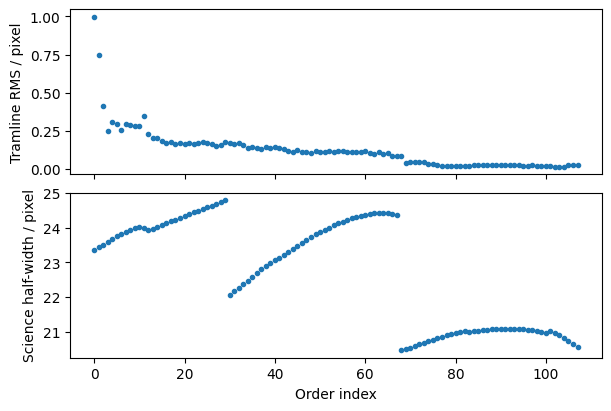

In [22]:
nightly_tramlines = tramlines.fit_nightly_tramlines(
    reduction_input,
    master_flat,
    detector_shifts,
    config,
    paths,
)

if (
    IN_NOTEBOOK
    and config.diagnostics != 'none'
):
    tramlines.show_summary(
        nightly_tramlines
    )

In [23]:
flat_products = flat.create_flat_products(
    master_flat,
    nightly_tramlines,
    config,
    paths,
)

DEBUG    ccd_1_order_167: created extracted Flat, response Flat and blaze
DEBUG    ccd_1_order_166: created extracted Flat, response Flat and blaze
DEBUG    ccd_1_order_165: created extracted Flat, response Flat and blaze
DEBUG    ccd_1_order_164: created extracted Flat, response Flat and blaze
DEBUG    ccd_1_order_163: created extracted Flat, response Flat and blaze
DEBUG    ccd_1_order_162: created extracted Flat, response Flat and blaze
DEBUG    ccd_1_order_161: created extracted Flat, response Flat and blaze
DEBUG    ccd_1_order_160: created extracted Flat, response Flat and blaze
DEBUG    ccd_1_order_159: created extracted Flat, response Flat and blaze
DEBUG    ccd_1_order_158: created extracted Flat, response Flat and blaze
DEBUG    ccd_1_order_157: created extracted Flat, response Flat and blaze
DEBUG    ccd_1_order_156: created extracted Flat, response Flat and blaze
DEBUG    ccd_1_order_155: created extracted Flat, response Flat and blaze
DEBUG    ccd_1_order_154: created extr

## 6. Extract wavelength-calibration observations

**Input:** SimLC and FibTh observations  
**Output:** time-stamped extracted calibration spectra

SimLC and FibTh are both used to establish the wavelength solution.

In [24]:
calibration_spectra = tramlines.extract_calibration_spectra(
    reduction_input,
    nightly_tramlines,
    config,
    paths
)

In [25]:
for calibration_type in ['SimTh','SimLC','FibTh']:
    tramlines.save_calibration_spectra(
        calibration_spectra[calibration_type],
        paths.wavelength / f'{calibration_type.lower()}.fits',
        calibration_type=calibration_type,
        overwrite=True,
    )

In [26]:
calibration_peak_tables = calibration.measure_calibration_peaks_for_night(
    calibration_spectra,
    output_dir=paths.wavelength,
    diagnostic_dir=paths.figures / 'calibration',
    maximum_signal={
        'SimLC': None,
        'SimTh': None,
        'FibTh': None,
    },
    log_level=config.log_level,
    diagnostics=config.diagnostics,
    overwrite=config.overwrite
)

Read in existing peak tables from /Users/buder/velocereduction/reductions/vr_0.7.0/001122/calibrations/wavelength, skipping peak measurement


## 7. Fit the wavelength solution

**Input:** extracted SimLC + FibTh spectra and their MJD timestamps  
**Output:** wavelength calibration model for the night

In [27]:
initial_wavelength_solution = (
    wavelength.load_initial_wavelength_solutions(
        paths.repository
    )
)

# VELOCE_CCD_ORDERS = {
#     "1": np.arange(167, 138 - 1, -1),
#     "2": np.arange(140, 103 - 1, -1),
#     "3": np.arange(104, 65 - 1, -1),
# }

# for ccd in [1, 2, 3]:
#     for type in ['SimTh','SimLC','FibTh']:
#         try:
#             all_coefficients = Table.read(paths.calibrations / f'wavelength/simlc_ccd{ccd}_wavelength_solution.fits',2)
#         except:
#             all_coefficients = Table.read(paths.calibrations / f'wavelength/fibth_ccd{ccd}_wavelength_solution.fits',2)

#         for order in VELOCE_CCD_ORDERS[str(ccd)]:
#             order_name = f'ccd_{ccd}_order_{order}'

#             coefficients = all_coefficients[all_coefficients['order'] == order]

#             initial_wavelength_solution[type][order_name] = np.array([coefficients['coefficient_'+str(i)][0] for i in range(0, 7)])

In [28]:
calibration_peak_tables["SimLC"] = (
    wavelength.identify_simlc_peaks(
        calibration_peak_tables["SimLC"],
        initial_wavelength_solution["SimLC"],
        detector_shifts,
    )
)

DEBUG    SimLC CCD2 wavelength fit iteration 1: 5682/5721 lines, robust scatter 0.0263 pix
DEBUG    SimLC CCD2 wavelength fit iteration 2: 5670/5721 lines, robust scatter 0.0259 pix
DEBUG    SimLC CCD2 wavelength fit iteration 3: 5667/5721 lines, robust scatter 0.0259 pix
DEBUG    SimLC CCD2 wavelength fit iteration 4: 5665/5721 lines, robust scatter 0.0258 pix
DEBUG    SimLC CCD2 wavelength fit iteration 5: 5663/5721 lines, robust scatter 0.0258 pix
DEBUG    SimLC CCD2 wavelength fit iteration 6: 5660/5721 lines, robust scatter 0.0259 pix
DEBUG    SimLC CCD2 wavelength fit iteration 7: 5659/5721 lines, robust scatter 0.0259 pix
DEBUG    SimLC CCD2 wavelength fit iteration 8: 5659/5721 lines, robust scatter 0.0258 pix
INFO     Saved SimLC CCD2 wavelength solution to /Users/buder/velocereduction/reductions/vr_0.7.0/001122/calibrations/wavelength/simlc_ccd2_wavelength_solution.fits


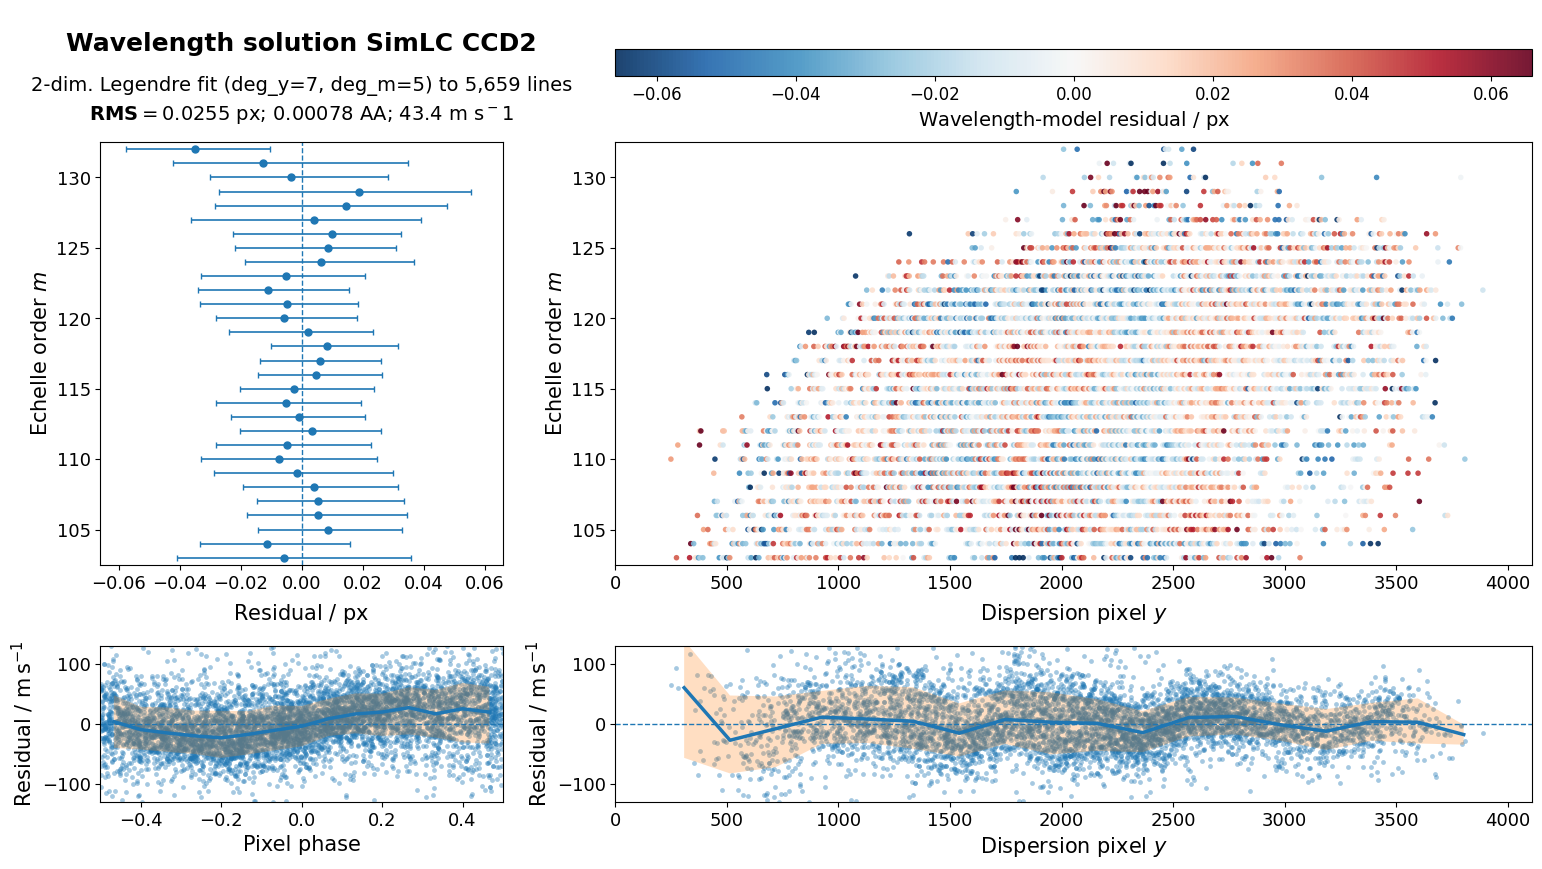

INFO     SimLC CCD2: 5659 lines, RMS 0.0255 pix / 0.00078 A / 43.4 m/s
DEBUG    SimLC CCD3 wavelength fit iteration 1: 8078/9252 lines, robust scatter 0.0943 pix
DEBUG    SimLC CCD3 wavelength fit iteration 2: 9007/9252 lines, robust scatter 0.0297 pix
DEBUG    SimLC CCD3 wavelength fit iteration 3: 9073/9252 lines, robust scatter 0.0301 pix
DEBUG    SimLC CCD3 wavelength fit iteration 4: 9101/9252 lines, robust scatter 0.0302 pix
DEBUG    SimLC CCD3 wavelength fit iteration 5: 9113/9252 lines, robust scatter 0.0303 pix
DEBUG    SimLC CCD3 wavelength fit iteration 6: 9121/9252 lines, robust scatter 0.0303 pix
DEBUG    SimLC CCD3 wavelength fit iteration 7: 9125/9252 lines, robust scatter 0.0303 pix
DEBUG    SimLC CCD3 wavelength fit iteration 8: 9133/9252 lines, robust scatter 0.0305 pix
DEBUG    SimLC CCD3 wavelength fit iteration 9: 9135/9252 lines, robust scatter 0.0305 pix
DEBUG    SimLC CCD3 wavelength fit iteration 10: 9137/9252 lines, robust scatter 0.0305 pix
INFO     Saved Sim

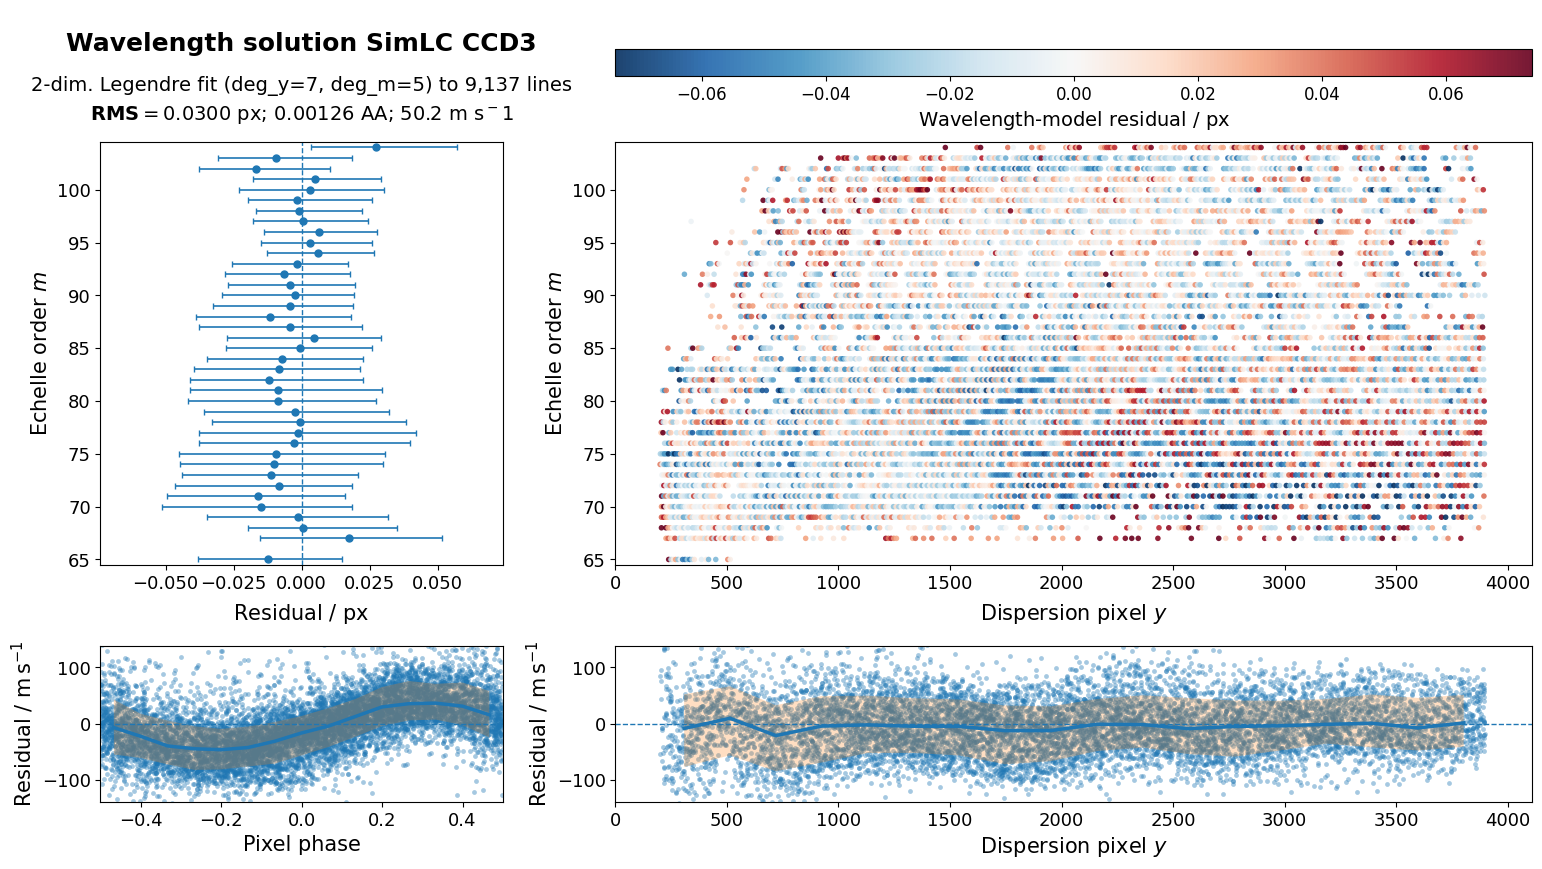

INFO     SimLC CCD3: 9137 lines, RMS 0.0300 pix / 0.00126 A / 50.2 m/s


In [29]:
simlc_wavelength_solutions = {}

for ccd in [2, 3]:

    simlc_wavelength_solutions[ccd] = (
        wavelength.fit_and_save_wavelength_surface(
            calibration_peak_tables["SimLC"],

            calibration_type="SimLC",
            ccd=ccd,

            degree_y=7,
            degree_m=5,

            minimum_y=200,
            maximum_y=3900,
            minimum_signal_to_noise=20,
            maximum_y_uncertainty=0.01,
            sigma_clip = 3.0,

            output_dir=paths.wavelength,
            diagnostic_dir=(
                paths.figures
                / "wavelength"
            ),

            diagnostics=config.diagnostics,
            overwrite=True,
        )
    )

# Update for FibTh

In [30]:
th_reference_lines = wavelength.load_th_reference_lines(paths, th_reference='murphy')

In [31]:
# Match fitted ThXe peaks to ThAr atlas lines

VELOCE_CCD_ORDERS = {
    "1": np.arange(167, 138 - 1, -1),
    "2": np.arange(140, 103 - 1, -1),
    "3": np.arange(104, 65 - 1, -1),
}

calibration_peak_tables["FibTh"]['closest_th_wavelength'] = np.zeros(len(calibration_peak_tables["FibTh"]), dtype=float)
calibration_peak_tables["FibTh"]['closest_th_wavelength'][:] = np.nan

for ccd in [1, 2, 3]:
    for order in VELOCE_CCD_ORDERS[str(ccd)]:
        indices = np.arange(len(calibration_peak_tables["FibTh"]))
        relevant_peak_indices = indices[(
            (calibration_peak_tables["FibTh"]["ccd"] == ccd)
            & (calibration_peak_tables["FibTh"]["order"] == order)
            & (calibration_peak_tables["FibTh"]["used_for_wavelength_fit"] == True)
        )]

        # y_values = np.arange(4112) - 2048 + detector_shifts['dy'][detector_shifts['ccd'] == ccd].value
        y_values = np.array(calibration_peak_tables["FibTh"][relevant_peak_indices]['y']) - 2048 + detector_shifts['dy'][detector_shifts['ccd'] == ccd].value

        expected_wavelength = np.array(
            np.polynomial.polynomial.polyval(
                y_values,
                initial_wavelength_solution['FibTh'][f'ccd_{ccd}_order_{order}'],
            )
        ) * 10.

        reference_th_lines_in_range = (
            (th_reference_lines['wave_vac'] > expected_wavelength.min())
            & (th_reference_lines['wave_vac'] < expected_wavelength.max())
            & (th_reference_lines['element'] == 'Th')
        )

        print(f'CCD {ccd}, order {order}: {len(calibration_peak_tables["FibTh"][relevant_peak_indices])} FibTh peaks, {len(th_reference_lines[reference_th_lines_in_range])} ThAr lines in range')

        # now loop over the FibTh peaks and find the closest ThAr line in the atlas
        for peak_index, original_index in enumerate(relevant_peak_indices):

            closest_th_line = np.argmin(
                np.abs(
                    th_reference_lines[reference_th_lines_in_range]['wave_vac']
                    - expected_wavelength[peak_index]
                )
            )

            closest_wave = th_reference_lines[reference_th_lines_in_range]['wave_vac'][closest_th_line]

            if np.abs(closest_wave - expected_wavelength[peak_index]) < 0.5:
                calibration_peak_tables["FibTh"][
                    'closest_th_wavelength'
                ][original_index] = closest_wave

CCD 1, order 167: 44 FibTh peaks, 32 ThAr lines in range
CCD 1, order 166: 42 FibTh peaks, 31 ThAr lines in range
CCD 1, order 165: 45 FibTh peaks, 32 ThAr lines in range
CCD 1, order 164: 44 FibTh peaks, 28 ThAr lines in range
CCD 1, order 163: 50 FibTh peaks, 31 ThAr lines in range
CCD 1, order 162: 55 FibTh peaks, 31 ThAr lines in range
CCD 1, order 161: 54 FibTh peaks, 36 ThAr lines in range
CCD 1, order 160: 43 FibTh peaks, 34 ThAr lines in range
CCD 1, order 159: 42 FibTh peaks, 28 ThAr lines in range
CCD 1, order 158: 40 FibTh peaks, 27 ThAr lines in range
CCD 1, order 157: 32 FibTh peaks, 41 ThAr lines in range
CCD 1, order 156: 44 FibTh peaks, 23 ThAr lines in range
CCD 1, order 155: 47 FibTh peaks, 25 ThAr lines in range
CCD 1, order 154: 57 FibTh peaks, 31 ThAr lines in range
CCD 1, order 153: 67 FibTh peaks, 42 ThAr lines in range
CCD 1, order 152: 57 FibTh peaks, 45 ThAr lines in range
CCD 1, order 151: 76 FibTh peaks, 50 ThAr lines in range
CCD 1, order 150: 84 FibTh peak

DEBUG    FibTh CCD1 wavelength fit iteration 1: 796/1034 lines, robust scatter 4.0305 pix
DEBUG    FibTh CCD1 wavelength fit iteration 2: 617/1034 lines, robust scatter 1.0887 pix
DEBUG    FibTh CCD1 wavelength fit iteration 3: 570/1034 lines, robust scatter 0.0977 pix
DEBUG    FibTh CCD1 wavelength fit iteration 4: 565/1034 lines, robust scatter 0.0468 pix
DEBUG    FibTh CCD1 wavelength fit iteration 5: 544/1034 lines, robust scatter 0.0424 pix
DEBUG    FibTh CCD1 wavelength fit iteration 6: 537/1034 lines, robust scatter 0.0384 pix
DEBUG    FibTh CCD1 wavelength fit iteration 7: 530/1034 lines, robust scatter 0.0372 pix
DEBUG    FibTh CCD1 wavelength fit iteration 8: 528/1034 lines, robust scatter 0.0355 pix
DEBUG    FibTh CCD1 wavelength fit iteration 9: 530/1034 lines, robust scatter 0.0347 pix
DEBUG    FibTh CCD1 wavelength fit iteration 10: 529/1034 lines, robust scatter 0.0335 pix
INFO     Saved FibTh CCD1 wavelength solution to /Users/buder/velocereduction/reductions/vr_0.7.0/0

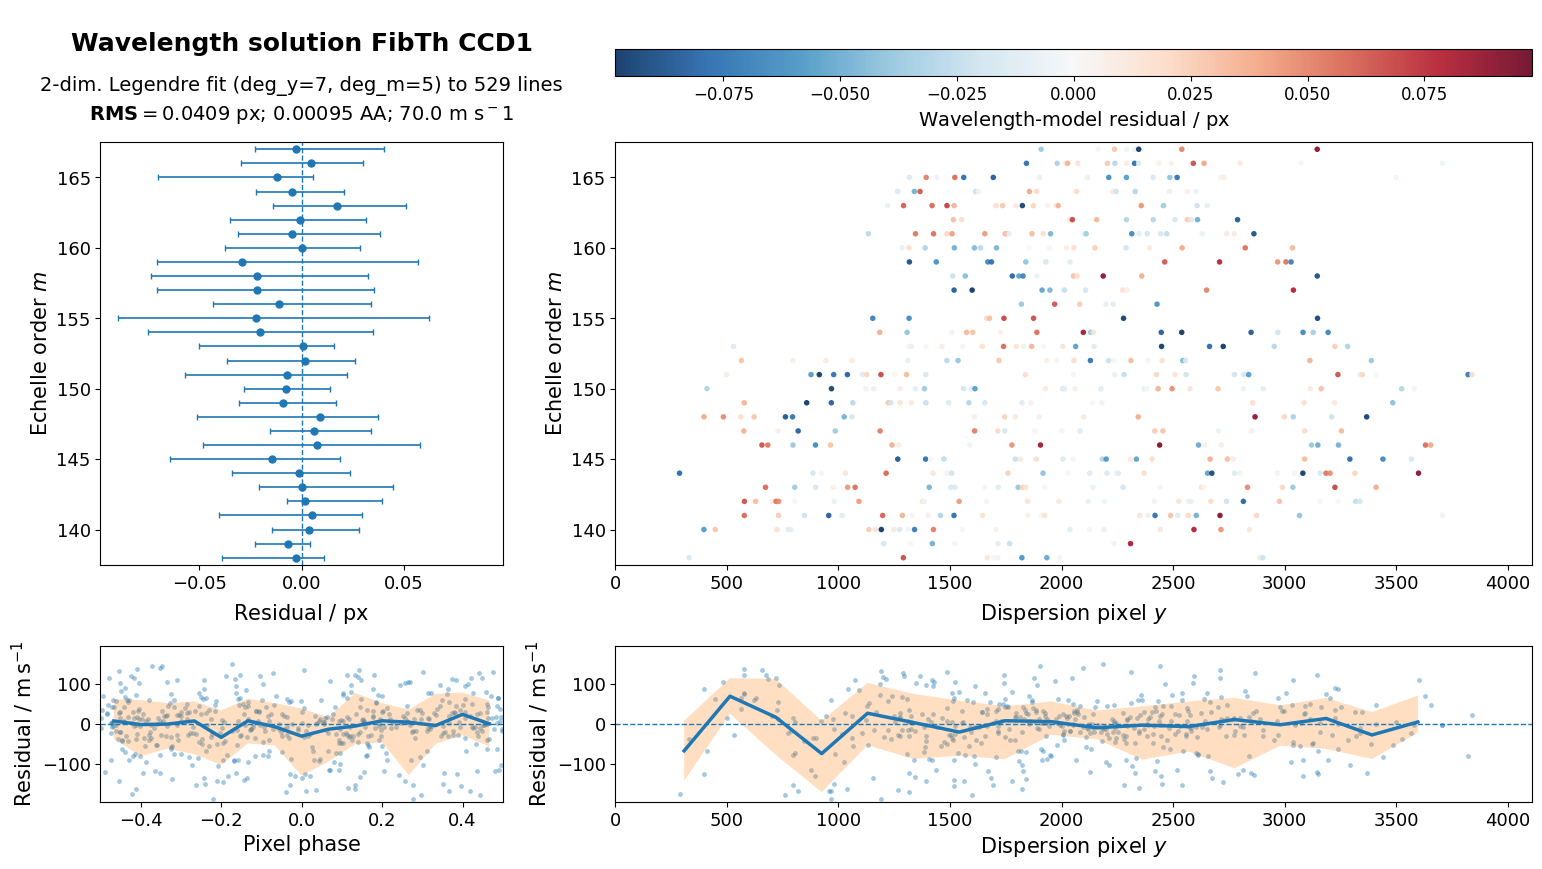

INFO     FibTh CCD1: 529 lines, RMS 0.0409 pix / 0.00095 A / 70.0 m/s
DEBUG    FibTh CCD2 wavelength fit iteration 1: 1040/1383 lines, robust scatter 2.4845 pix
DEBUG    FibTh CCD2 wavelength fit iteration 2: 922/1383 lines, robust scatter 1.1726 pix
DEBUG    FibTh CCD2 wavelength fit iteration 3: 890/1383 lines, robust scatter 0.2974 pix
DEBUG    FibTh CCD2 wavelength fit iteration 4: 885/1383 lines, robust scatter 0.1403 pix
DEBUG    FibTh CCD2 wavelength fit iteration 5: 865/1383 lines, robust scatter 0.0724 pix
DEBUG    FibTh CCD2 wavelength fit iteration 6: 842/1383 lines, robust scatter 0.0644 pix
DEBUG    FibTh CCD2 wavelength fit iteration 7: 822/1383 lines, robust scatter 0.0567 pix
DEBUG    FibTh CCD2 wavelength fit iteration 8: 800/1383 lines, robust scatter 0.0504 pix
DEBUG    FibTh CCD2 wavelength fit iteration 9: 789/1383 lines, robust scatter 0.0478 pix
DEBUG    FibTh CCD2 wavelength fit iteration 10: 785/1383 lines, robust scatter 0.0465 pix
INFO     Saved FibTh CCD2 wa

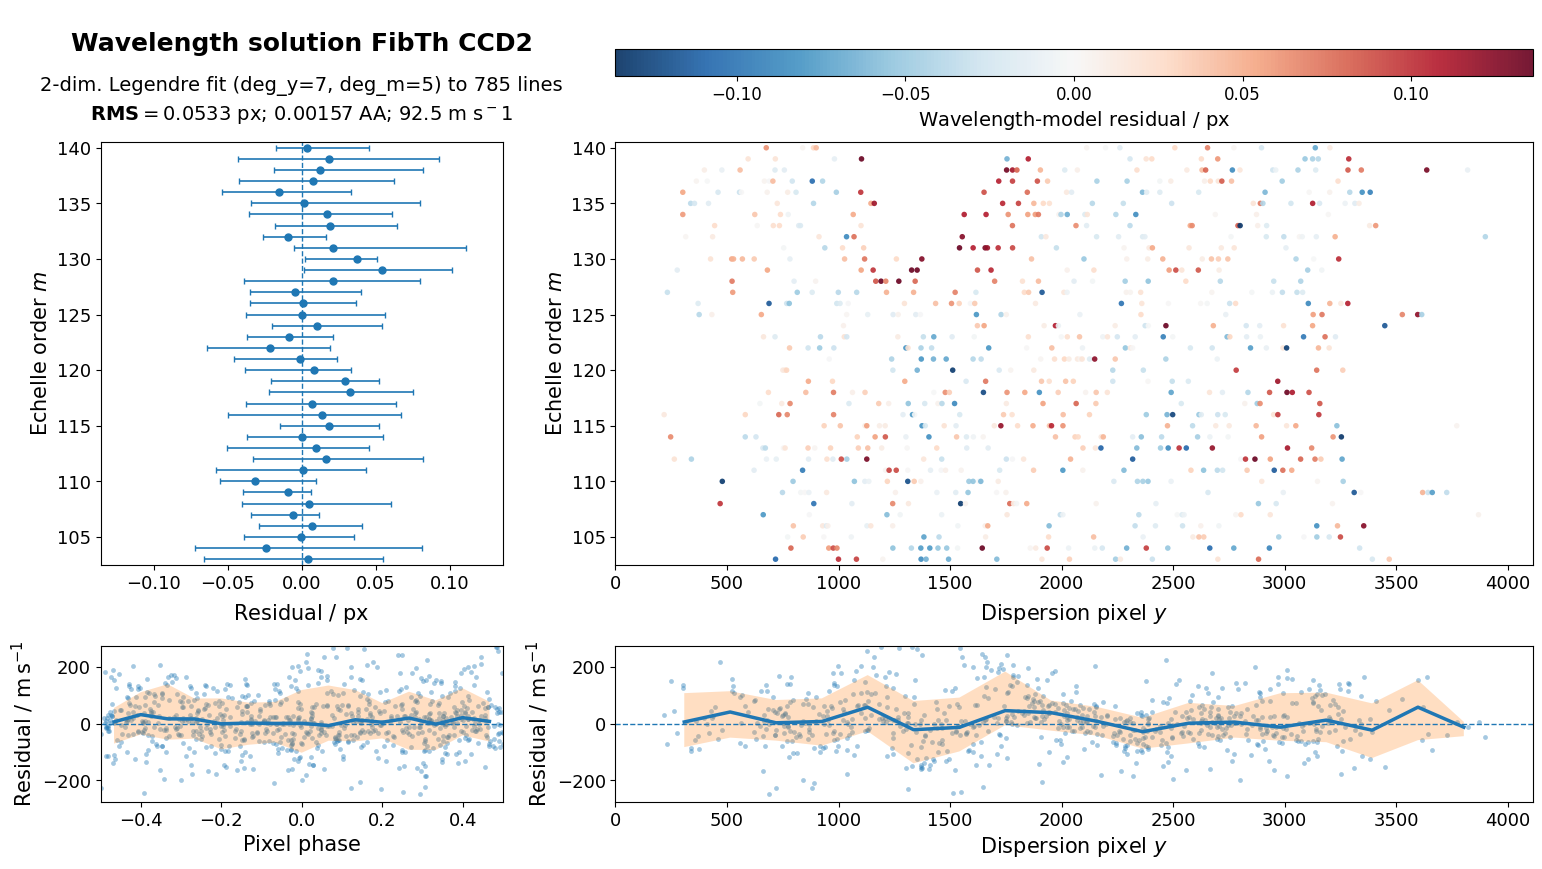

INFO     FibTh CCD2: 785 lines, RMS 0.0533 pix / 0.00157 A / 92.5 m/s
DEBUG    FibTh CCD3 wavelength fit iteration 1: 616/822 lines, robust scatter 0.8998 pix
DEBUG    FibTh CCD3 wavelength fit iteration 2: 586/822 lines, robust scatter 0.1119 pix
DEBUG    FibTh CCD3 wavelength fit iteration 3: 549/822 lines, robust scatter 0.0505 pix
DEBUG    FibTh CCD3 wavelength fit iteration 4: 530/822 lines, robust scatter 0.0381 pix
DEBUG    FibTh CCD3 wavelength fit iteration 5: 525/822 lines, robust scatter 0.0365 pix
DEBUG    FibTh CCD3 wavelength fit iteration 6: 525/822 lines, robust scatter 0.0361 pix
INFO     Saved FibTh CCD3 wavelength solution to /Users/buder/velocereduction/reductions/vr_0.7.0/001122/calibrations/wavelength/fibth_ccd3_wavelength_solution.fits


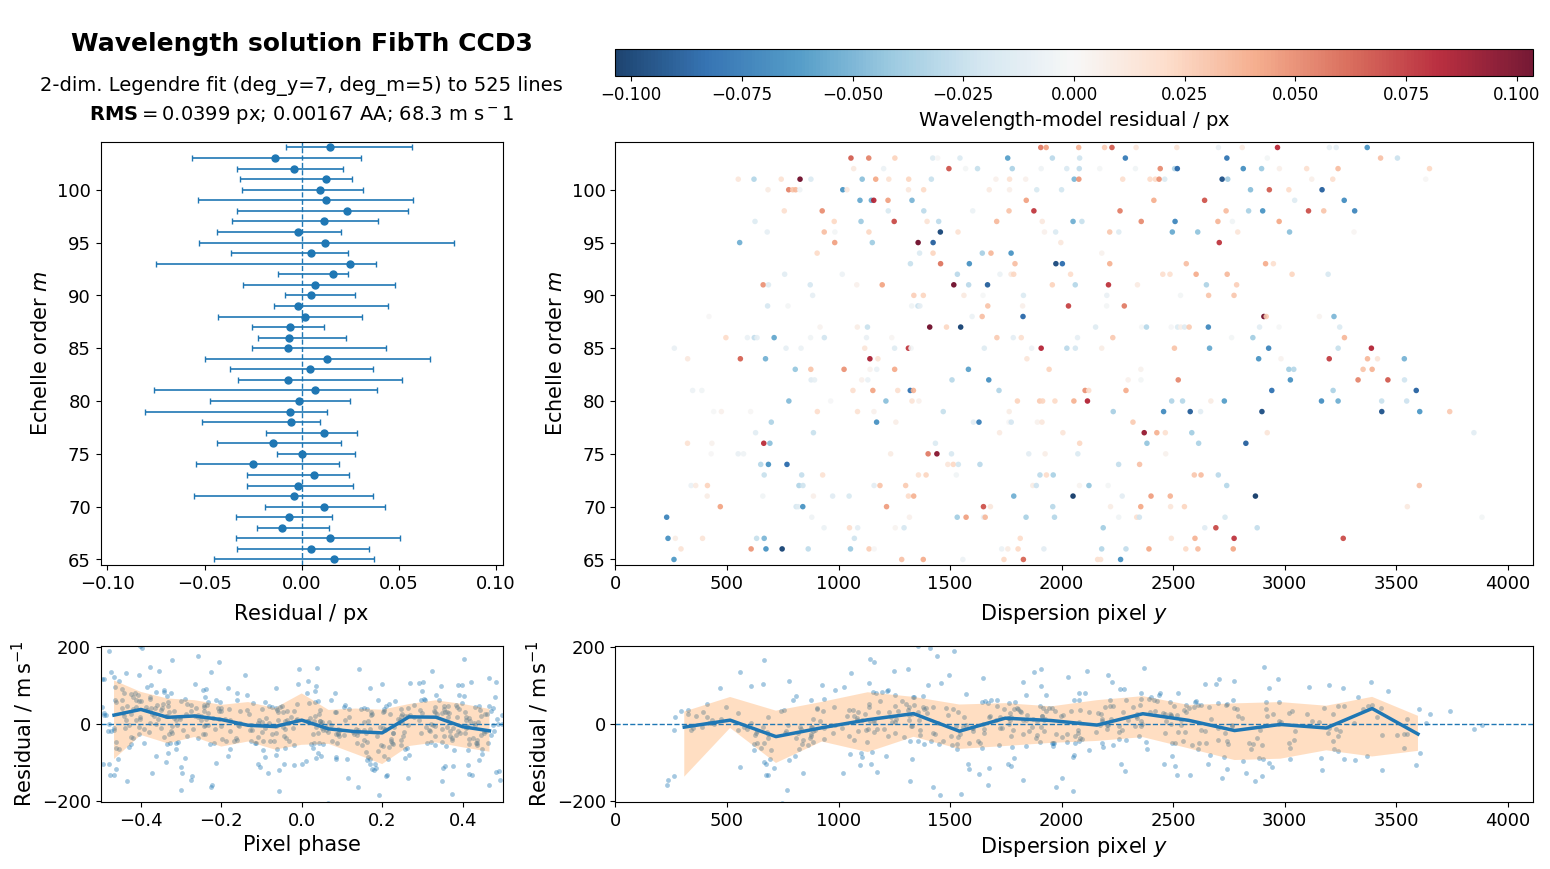

INFO     FibTh CCD3: 525 lines, RMS 0.0399 pix / 0.00167 A / 68.3 m/s


In [39]:
fibth_wavelength_solutions = {}

for ccd in [1, 2, 3]:

    fibth_wavelength_solutions[ccd] = (
        wavelength.fit_and_save_wavelength_surface(
            calibration_peak_tables["FibTh"],

            calibration_type="FibTh",
            ccd=ccd,

            degree_y=7,
            degree_m=5,

            minimum_y=200,
            maximum_y=3900,
            minimum_signal_to_noise=3,
            maximum_y_uncertainty=0.5,
            sigma_clip = 3.0,

            output_dir=paths.wavelength,
            diagnostic_dir=(
                paths.figures
                / "wavelength"
            ),

            diagnostics=config.diagnostics,
            overwrite=True,
        )
    )

In [33]:
speed_of_light_mps = 299792458.0

simlc_fibth_comparison = {}

for ccd in [2, 3]:

    simlc_solution = simlc_wavelength_solutions[ccd]
    fibth_solution = fibth_wavelength_solutions[ccd]

    # Orders that physically exist on this CCD.
    orders = VELOCE_CCD_ORDERS[str(ccd)]

    # I would initially compare only the well-constrained central
    # detector region used in the fits.
    y_grid = np.arange(
        200,
        3901,
        dtype=float,
    )

    comparison = {}

    for order in orders:

        m_grid = np.full(
            len(y_grid),
            float(order),
        )

        wavelength_simlc = (
            wavelength.evaluate_wavelength_surface(
                y_grid,
                m_grid,
                simlc_solution["coefficients"],
                simlc_solution["normalisation"],
            )
        )

        wavelength_fibth = (
            wavelength.evaluate_wavelength_surface(
                y_grid,
                m_grid,
                fibth_solution["coefficients"],
                fibth_solution["normalisation"],
            )
        )

        delta_wavelength = (
            wavelength_fibth
            - wavelength_simlc
        )

        delta_velocity = (
            speed_of_light_mps
            * delta_wavelength
            / wavelength_fibth
        )

        comparison[int(order)] = {
            "y": y_grid.copy(),
            "delta_wavelength": delta_wavelength,
            "delta_velocity": delta_velocity,
            "median_velocity": np.nanmedian(
                delta_velocity
            ),
        }

    simlc_fibth_comparison[ccd] = comparison

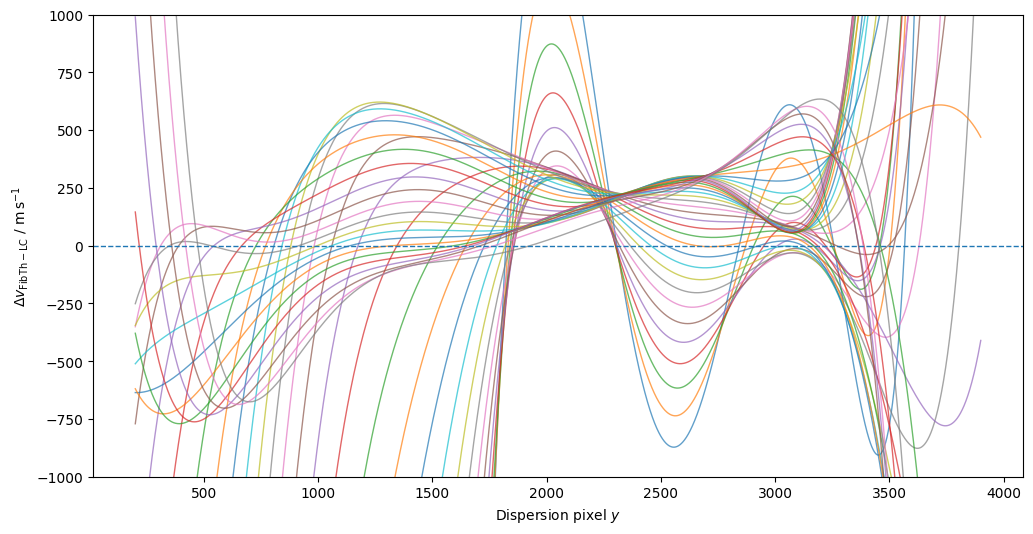

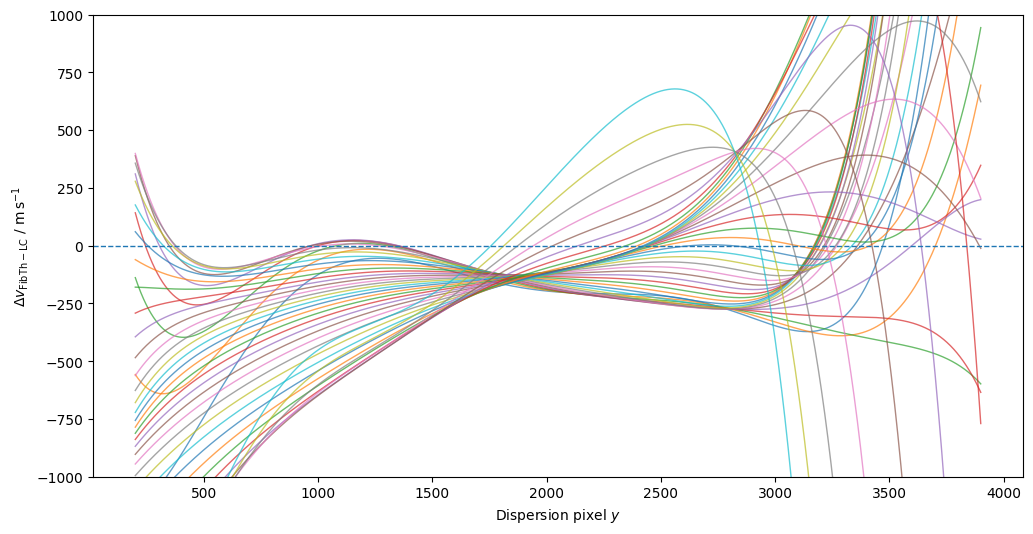

In [34]:
for ccd in [2, 3]:
    fig, ax = plt.subplots(
        figsize=(12, 6),
    )

    for order, order_data in simlc_fibth_comparison[ccd].items():

        ax.plot(
            order_data["y"],
            order_data["delta_velocity"],
            lw=1,
            alpha=0.7,
        )

    ax.axhline(
        0,
        ls="--",
        lw=1,
    )

    ax.set_xlabel(
        r"Dispersion pixel $y$"
    )

    ax.set_ylabel(
        r"$\Delta v_{\rm FibTh-LC}~/~\mathrm{m\,s^{-1}}$"
    )

    plt.ylim(-1000,1000)

    plt.show()
    plt.close()

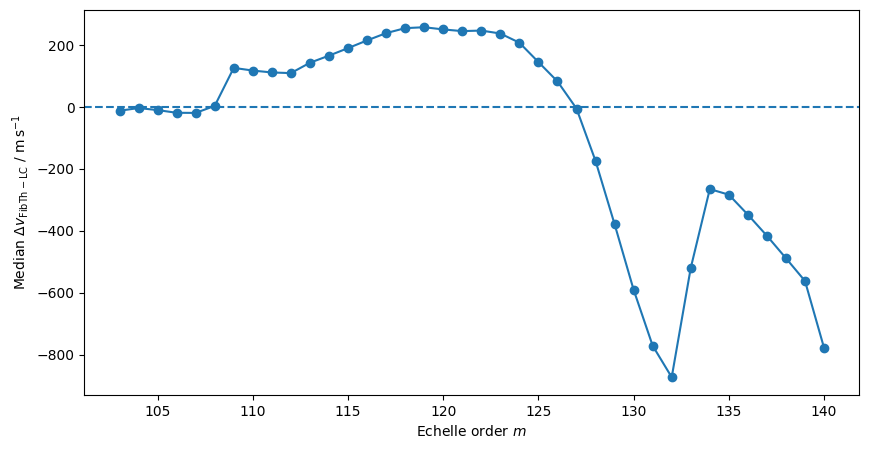

In [35]:
orders = np.array(
    list(
        simlc_fibth_comparison[2].keys()
    )
)

median_velocity = np.array(
    [
        simlc_fibth_comparison[2][order][
            "median_velocity"
        ]
        for order in orders
    ]
)

plt.figure(
    figsize=(10, 5)
)

plt.plot(
    orders,
    median_velocity,
    "o-",
)

plt.axhline(
    0,
    ls="--",
)

plt.xlabel(
    r"Echelle order $m$"
)

plt.ylabel(
    r"Median $\Delta v_{\rm FibTh-LC}~/~"
    r"\mathrm{m\,s^{-1}}$"
)

plt.show()

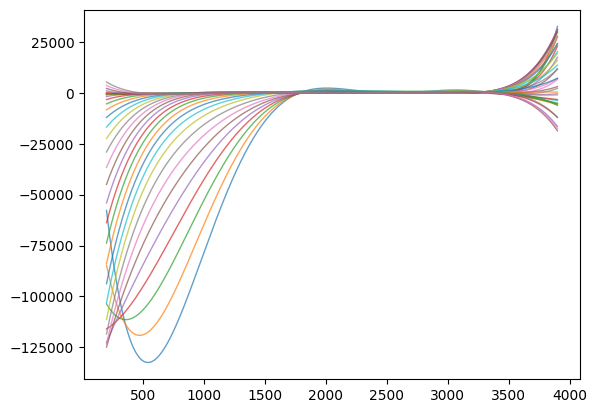

In [36]:
for order, order_data in simlc_fibth_comparison[2].items():

    delta_velocity_relative = (
        order_data["delta_velocity"]
        - order_data["median_velocity"]
    )

    plt.plot(
        order_data["y"],
        delta_velocity_relative,
        lw=1,
        alpha=0.7,
    )

In [37]:
median = np.nanmedian(
    delta_velocity
)

p16, p84 = np.nanpercentile(
    delta_velocity,
    [16, 84],
)

coeff = np.polyfit(
    y_grid,
    delta_velocity,
    1,
)

slope = coeff[0]

# AND NOW ON TO FibTh and SimTh!

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

profile = np.array([
    81.57262, 82.74879, 84.07484, 85.51365, 87.305565,
    89.30765, 91.70762, 95.04747, 103.25724, 187.9351,
    856.6781, 1623.3531, 1191.6061, 1605.9312, 1380.1094,
    382.45584, 176.25848, 604.99426, 1762.9586, 1599.2748,
    1561.6721, 1962.3041, 1625.9062, 2022.3882, 1294.7383,
    1659.822, 1832.4697, 1595.2172, 1885.2881, 1115.4753,
    1632.6721, 1746.5565, 1762.3352, 2053.2246, 1477.6094,
    2021.2198, 1392.0208, 1542.4307, 2038.9489, 1626.499,
    2133.77, 1510.3711, 1855.7716, 1824.5089, 1558.361,
    2057.669, 1420.9939, 1948.443, 1699.8217, 1825.9548,
    2228.4048, 1639.69, 2232.546, 1675.7391, 2038.3729,
    1905.6105, 1585.1754, 2203.74, 1496.3717, 2093.3496,
    1956.5414, 1926.3536, 1942.1548, 606.71, 186.84503,
    487.95825, 1596.2225, 1678.0306, 1461.7289, 1809.1649,
    1252.9032, 1883.7676, 1356.7611, 295.69467, 111.47796,
    96.30301, 91.46026, 88.387535, 86.011986, 83.81893,
    82.0248
])

# Pixel coordinates, with the central profile pixel at x=0
x = np.arange(len(profile)) - (len(profile) - 1) / 2


# ---------------------------------------------------------------------
# Fibre geometry
#
# left sky:       -12, -11
# blank:          -10
# science:         -9 ... +9       (19 fibres)
# blank:          +10
# right sky:      +11, +12, +13
#
# Actual position = x0 + slot * separation
# ---------------------------------------------------------------------

sky_left_slots  = np.array([-12, -11])
science_slots   = np.arange(-9, 10)
sky_right_slots = np.array([11, 12, 13])

fibre_slots = np.concatenate([
    sky_left_slots,
    science_slots,
    sky_right_slots
])

n_fibres = len(fibre_slots)   # 24


def gaussian_model(params, x):
    """
    params =
        [background, x0, separation, sigma, amplitude_0, ..., amplitude_23]
    """

    background = params[0]
    x0         = params[1]
    separation = params[2]
    sigma      = params[3]
    amplitudes = params[4:]

    centres = x0 + separation * fibre_slots

    model = np.full_like(x, background, dtype=float)

    for amplitude, centre in zip(amplitudes, centres):
        model += amplitude * np.exp(
            -0.5 * ((x - centre) / sigma)**2
        )

    return model


def residuals(params, x, y):
    return gaussian_model(params, x) - y


# ---------------------------------------------------------------------
# Initial guesses
# ---------------------------------------------------------------------

background_init = np.median(
    np.concatenate([profile[:8], profile[-8:]])
)

x0_init = 0.0
separation_init = 2.4
sigma_init = 0.85

centres_init = x0_init + separation_init * fibre_slots

# Estimate each amplitude from the closest pixel
amplitudes_init = []

for centre in centres_init:
    idx = np.argmin(np.abs(x - centre))
    amplitudes_init.append(
        max(profile[idx] - background_init, 10)
    )

amplitudes_init = np.array(amplitudes_init)

p0 = np.concatenate([
    [
        background_init,
        x0_init,
        separation_init,
        sigma_init
    ],
    amplitudes_init
])


# ---------------------------------------------------------------------
# Bounds
# ---------------------------------------------------------------------

lower_bounds = np.concatenate([
    [
        0,       # background
        -1.0,    # central-fibre offset
        2.0,     # separation
        0.3      # sigma
    ],
    np.zeros(n_fibres)
])

upper_bounds = np.concatenate([
    [
        500,     # background
        +1.0,    # central-fibre offset
        2.8,     # separation
        2.0      # sigma
    ],
    np.full(n_fibres, 5000)
])


# ---------------------------------------------------------------------
# Fit
# ---------------------------------------------------------------------

result = least_squares(
    residuals,
    p0,
    args=(x, profile),
    bounds=(lower_bounds, upper_bounds),
    max_nfev=20000
)

popt = result.x

background = popt[0]
x0         = popt[1]
separation = popt[2]
sigma      = popt[3]
amplitudes = popt[4:]

centres = x0 + separation * fibre_slots

model = gaussian_model(popt, x)
resid = profile - model

print(f"Background = {background:.3f}")
print(f"x0         = {x0:.4f} pix")
print(f"Separation = {separation:.4f} pix")
print(f"sigma      = {sigma:.4f} pix")
print(f"FWHM       = {2.35482 * sigma:.4f} pix")
print(f"RMS        = {np.sqrt(np.mean(resid**2)):.3f}")

print("\nFibre centres:")
for i, (slot, centre, amplitude) in enumerate(
    zip(fibre_slots, centres, amplitudes)
):
    if slot in science_slots:
        fibre_type = "Science"
    else:
        fibre_type = "Sky"

    print(
        f"{i:2d}  {fibre_type:7s}  "
        f"slot={slot:+3d}  "
        f"x={centre:+7.3f}  "
        f"A={amplitude:8.1f}"
    )


# ---------------------------------------------------------------------
# Plot
# ---------------------------------------------------------------------

xx = np.linspace(x.min(), x.max(), 3000)
model_fine = gaussian_model(popt, xx)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(x, profile, "o", label="Profile")
ax.plot(xx, model_fine, "-", label="Gaussian model")

# Plot individual Gaussian components
for amplitude, centre in zip(amplitudes, centres):

    component = (
        background
        + amplitude
        * np.exp(-0.5 * ((xx - centre) / sigma)**2)
    )

    ax.plot(xx, component, alpha=0.35)

# fibre centres
for slot, centre in zip(fibre_slots, centres):

    if slot in science_slots:
        ax.axvline(centre, lw=0.5, alpha=0.3)
    else:
        ax.axvline(centre, lw=0.5, ls="--", alpha=0.5)

# blank fibre locations
blank_slots = [-10, 10]

for slot in blank_slots:
    blank_centre = x0 + slot * separation
    ax.axvline(
        blank_centre,
        ls=":",
        lw=1.5,
        label="Blank fibre" if slot == -10 else None
    )

ax.set_xlabel("Cross-dispersion pixel relative to central fibre")
ax.set_ylabel("Flux")
ax.legend()

plt.tight_layout()

plt.savefig(
    paths.figures / "calibration/fibre_profile_fit.pdf",
    bbox_inches="tight"
)

plt.show()

## 8. Dark Products

In [ ]:
# dark_products = utils.process_darks(
#     processed,
#     config,
#     paths
# ) 

## 9. Extract science spectra

**Input:** processed Science images + tramlines + Flat products + wavelength model  
**Output:** wavelength-calibrated Science spectra

The current default extraction is summed across the Science fibres.
A fibre-resolved extraction can use the same interface in future.

In [ ]:
# science_spectra = extraction.extract_science(
#     processed.science,
#     nightly_tramlines,
#     flat_products,
#     wavelength_solution,
#     config,
#     paths
# )

## 10. Velocities

**Input:** wavelength-calibrated Science spectra  
**Output:** barycentric corrections and first-pass radial velocities

In [ ]:
# science_spectra = velocities.add_barycentric_corrections(
#     science_spectra,
#     config,
#     paths
# )

# science_spectra = velocities.measure_initial_rvs(
#     science_spectra,
#     template='solar',
#     config=config,
#     paths=paths
# )

## 11. B-star and telluric products

**Input:** B-star observations  
**Output:** extracted B-star spectra and telluric measurements

In [ ]:
# bstar_spectra = extraction.extract_science(
#     processed.bstars,
#     nightly_tramlines,
#     flat_products,
#     wavelength_solution,
#     config,
#     paths,
#     product_type='Bstar'
# )

# telluric_products = tellurics.measure_tellurics(
#     bstar_spectra,
#     config,
#     paths
# )

## 12. Final products and reduction summary

Write the final Science FITS products, retained diagnostic figures, and
human-readable summary of the night.

In [ ]:
# utils.write_science_products(
#     science_spectra,
#     config,
#     paths
# )

# summary = utils.create_reduction_summary(
#     reduction_input=reduction_input,
#     detector_shifts=detector_shifts,
#     tramlines=nightly_tramlines,
#     wavelength_solution=wavelength_solution,
#     science_spectra=science_spectra,
#     config=config,
#     paths=paths
# )

# utils.write_reduction_summary(summary, config, paths)

In [ ]:
logger.info('Reduction completed successfully.')

print()
print('Reduction complete')
print(f'Night:    {night}')
print(f'Version:  {__version__}')
print(f'Products: {paths.root}')
print(f'Summary:  {paths.reduction_summary}')